# One constraint spec, six models

A visual comparison of the fitted-joint engines on a *hand-specified*
distribution over four variables `x0..x3` on `[0, 100]` — the same spec
translated into each model's native constraint grammar:

| # | constraint | type |
|---|---|---|
| 1 | `E[x0] = 65` | expectation |
| 2 | `E[x2] = 49` | expectation |
| 3 | `E[x3] = 50` | expectation |
| 4 | `P(x1 > 60) = 0.30` | tail indicator |
| 5 | `P(x1 > 60 \| x0 > 70) = 0.60` | conditional probability |
| 6 | `P(x1 < 30 \| x0 < 40) = 0.55` | conditional probability |
| 7 | `E[x2 \| x1 > 60] = 70` | conditional expectation |
| 8 | `E[x2 \| x1 < 60] = 40` | conditional expectation |
| 9 | `cov(x2, x3) = -250` | covariance |
| 10 | `P(x0 > 70, x3 > 70) = 0.15` | joint tail indicator |

The set is (mostly) self-consistent — #2 is the total-probability anchor for
#4/#7/#8 (`0.30*70 + 0.70*40 = 49`) — and its dependency graph is a **loop**:

```
x0 —(5,6)— x1 —(7,8)— x2 —(9)— x3 —(10)— x0
```

The chain is ordered `x0-x1-x2-x3`, so the closing `x0-x3` edge must be carried
through every bond; the balanced tree routes it through the root instead. The
`x1->x2` push is positive while `cov(x2,x3) < 0` yet `x0,x3` are positively
tied — hitting all ten at once takes coordinated dependence. Some model
classes manage it (nearly) exactly; the interesting comparison is *how*, and
what each does with the freedom the spec leaves open.

**Models** (one color each, constant across every figure — CVD-validated set):

| | model | machinery |
|---|---|---|
| <span style="color:#999999">**gray**</span> | independent | bond-1 tensor chain — the best *product* distribution for this spec |
| <span style="color:#E69F00">**orange**</span> | chain | Born `TensorChain`, bond 8, entropy + `core_tv` regularisers, exact contractions |
| <span style="color:#882255">**wine**</span> | tree | Born `TensorTree`, bond 8, balanced latent tree (benchmark topology), entropy + `core_tv` |
| <span style="color:#0072B2">**blue**</span> | flow | RealNVP sampler, exact-entropy maxent |
| <span style="color:#117733">**green**</span> | gaussian | single joint `N(mu, Sigma)` (`pc.GaussianModel`), closed-form Phi queries |
| <span style="color:#56B4E9">**sky**</span> | copula | Gaussian copula: exact histogram marginals + correlation `R` (benchmark engine) |

In [1]:
import os
os.environ.setdefault("JAX_PLATFORMS", "cpu")
import sys, pathlib, time, types
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# benchmarks/ is a top-level repo package (not installed) — put the root on the path
ROOT = next(p for p in [pathlib.Path.cwd(), *pathlib.Path.cwd().parents]
            if (p / "benchmarks").is_dir())
sys.path.insert(0, str(ROOT))

from calibrated_response.tn import ContinuousVar, plot_pairwise as tn_plot_pairwise
from calibrated_response.tn.chain import TensorChain
from calibrated_response.tn.tree import TensorTree
from calibrated_response.tn.losses import combined_loss
from calibrated_response.maxent_sampler import (
    FlowSamplerModel, moment, soft_gt, soft_lt,
    plot_pairwise as flow_plot_pairwise)
from calibrated_response.pc import GaussianModel, TrainConfig, VarSpec, train
from benchmarks.engines import TensorTreeEngine, GaussianCopulaEngine
from benchmarks.encoding import TableEncoder
from benchmarks.constraints import (Interval, MarginalConstraint, ProbConstraint,
                                    CondProbConstraint, CondExpectConstraint)

NBINS, SPAN, NV = 20, 100.0, 4
vars_ = [ContinuousVar(f"x{i}", 0.0, 100.0, NBINS) for i in range(NV)]
names = [v.name for v in vars_]
centers = (np.arange(NBINS, dtype=np.float32) + 0.5) * (SPAN / NBINS)

COLOR = {"independent": "#999999", "chain": "#E69F00", "tree": "#882255",
         "flow": "#0072B2", "gaussian": "#117733", "copula": "#56B4E9"}
CMAP = {"independent": "Greys", "chain": "Oranges", "tree": "RdPu",
        "flow": "Blues", "gaussian": "Greens", "copula": "PuBu"}

# ---- the spec, tensor-network grammar (hard bin masks; thresholds sit on
# ---- bin edges, so the masks are exact) --------------------------------
mgt = lambda thr: (centers > thr).astype(np.float32)
mlt = lambda thr: (centers < thr).astype(np.float32)
W_E = (1.0 / SPAN) ** 2                # normalise expectation errors to spans
W_XY = (1.0 / 2500.0) ** 2             # ... and E[x*y] errors to (span/2)^2

tn_csts = [
    ("expect", {0: centers}, 65.0, W_E),
    ("expect", {2: centers}, 49.0, W_E),
    ("expect", {3: centers}, 50.0, W_E),
    ("prob", {1: mgt(60)}, 0.30),
    ("cond", {1: mgt(60)}, {0: mgt(70)}, 0.60),
    ("cond", {1: mlt(30)}, {0: mlt(40)}, 0.55),
    ("cond_expect", 2, {1: mgt(60)}, 70.0, W_E),
    ("cond_expect", 2, {1: mlt(60)}, 40.0, W_E),
    # cov via the uncentred moment: E[x2*x3] = cov + E[x2]E[x3] = -250 + 49*50
    ("expect", ((2, 3), np.outer(centers, centers)), 2200.0, W_XY),
    ("prob", {0: mgt(70), 3: mgt(70)}, 0.15),
]

# ---- the same spec, flow-sampler grammar (soft indicators inside the loss
# ---- only; sharpness 0.3 on the [0,100] domain; w = 1/(2 sd^2)) --------
SH = 0.3
W_P, W_EF, W_C = 200.0, 0.02, 3.2e-5   # sd: 0.05 (prob), 5 (E), 125 (cov)
conj = lambda f, g: (lambda x: f(x) * g(x))

fl_csts = [
    ("expect", moment(0), 65.0, W_EF),
    ("expect", moment(2), 49.0, W_EF),
    ("expect", moment(3), 50.0, W_EF),
    ("expect", soft_gt(1, 60.0, SH), 0.30, W_P),
    ("cond_expect", soft_gt(1, 60.0, SH), soft_gt(0, 70.0, SH), 0.60, W_P),
    ("cond_expect", soft_lt(1, 30.0, SH), soft_lt(0, 40.0, SH), 0.55, W_P),
    ("cond_expect", moment(2), soft_gt(1, 60.0, SH), 70.0, W_EF),
    ("cond_expect", moment(2), soft_lt(1, 60.0, SH), 40.0, W_EF),
    ("cov", moment(2), moment(3), -250.0, W_C),
    ("expect", conj(soft_gt(0, 70.0, SH), soft_gt(3, 70.0, SH)), 0.15, W_P),
]
print(f"{len(tn_csts)} constraints in each grammar")
fits = {}

10 constraints in each grammar


### Fit — tensor networks

Same recipe as the benchmark engines: constraint SSE + regularisers by Adam on
exact contractions. The chain **and the tree** get **`core_tv`** on top of the
entropy term — a first-difference smoother on the raw cores that discourages
bin-to-bin spikes. It applies per node core on either topology; the tree's
dim-1 latent junctions are skipped (there is no bin axis to smooth — naively
differencing them is what used to turn the loss NaN). Weights: 3.0 on the
chain (the reference value from `tn_chain_born.ipynb`) but **1.0 on the tree**
— the tree is more sensitive (all its physical content lives in four small
leaf cores), and at 3.0 it trades real constraint residual (cov -149 vs -250)
for no extra smoothness; 1.0 keeps the fit near-exact with the same marginal
TV. The tree reuses the benchmark's balanced-latent-tree topology builder. The bond-1 chain can
only represent `p(x0)p(x1)p(x2)p(x3)` — it is the *independent null* fit to
the identical constraint list.

In [2]:
tn_specs = {
    "independent": (TensorChain(vars_, bond_dim=1, kind="born"),
                    (("entropy", 1e-3),)),
    "chain": (TensorChain(vars_, bond_dim=8, kind="born"),
              (("entropy", 1e-3), ("core_tv", 3.0))),
}
tvars, tedges = TensorTreeEngine()._build_tree(
    types.SimpleNamespace(names=names, tn_vars=lambda: list(vars_)))
tn_specs["tree"] = (TensorTree(tvars, edges=tedges, bond_dim=8, kind="born"),
                    (("entropy", 1e-3), ("core_tv", 1.0)))

for label, (m, regs) in tn_specs.items():
    t0 = time.time()
    p, h = m.optimize(combined_loss(m, tn_csts, regularizers=regs),
                      backend="adam", seed=0,
                      init=m.init_params(seed=0, init="uniform"),
                      steps=2000, lr=2e-2)
    fits[label] = (m, p)
    print(f"{label:<12s} loss {h[0]:.3f} -> {h[-1]:.5f}   ({time.time()-t0:.0f}s)")

independent  loss 0.198 -> 0.09450   (22s)


chain        loss 0.203 -> -0.00236   (34s)


tree         loss 0.202 -> -0.00014   (73s)


### Fit — flow, gaussian, copula

- **flow**: constraint penalties − exact joint entropy (`entropy_reg=1.0`),
  fresh 2048-sample latent batch per Adam step.
- **gaussian**: `pc.GaussianModel` — every constraint in the spec is a <=2-var
  quantity with a **closed form** under `N(mu, Sigma)` (Phi / bivariate Phi /
  truncated-Gaussian moments), and `cov(x2,x3)` is literally an entry of
  `Sigma`. No entropy term and no Monte Carlo anywhere in the fit.
- **copula**: the benchmark `GaussianCopulaEngine`, fit the way copulas are
  meant to be used — marginals first, dependence second. Stage 1 turns each
  variable's *single-variable* statements into a 1-D maxent histogram
  (exponential tilt for `E[x]`, two-level for the `P(x1>60)` split); stage 2
  learns the correlation matrix `R` from the dependence statements. The copula
  grammar has **no covariance statement**, so #9 is translated into its nearest
  expressible form — the half-conditional means `E[x3|x2>50]=40`,
  `E[x3|x2<50]=60` (exact for step dependence, an over-ask for graded Gaussian
  dependence; the table shows what that translation costs).

In [3]:
t0 = time.time()
fm = FlowSamplerModel(vars_, n_layers=8, hidden=256)
fp, fh = fm.optimize(fm.constraint_loss(fl_csts, n_samples=2048, entropy_reg=0.4, weight_reg=0.05),
                     steps=1500, lr=1e-3)
fits["flow"] = (fm, fp)
x_flow = fm.sample(fp, 200_000, seed=7)
print(f"flow     loss {fh[0]:.2f} -> {np.mean(fh[-100:]):.3f}   "
      f"({time.time()-t0:.0f}s)   exact H = {fm.entropy(fp):.2f} nats")

flow     loss 48.79 -> -6.316   (100s)   exact H = 17.24 nats


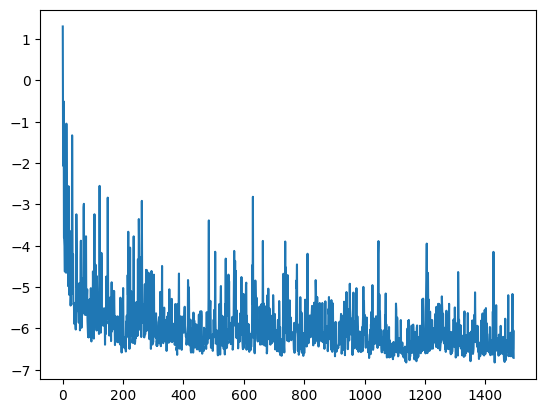

In [4]:
plt.plot(fh[5:])
# plt.yscale("log")
plt.show()

(<Figure size 960x960 with 16 Axes>,
 array([[<Axes: ylabel='x0'>, <Axes: >, <Axes: >, <Axes: >],
        [<Axes: ylabel='x1'>, <Axes: >, <Axes: >, <Axes: >],
        [<Axes: ylabel='x2'>, <Axes: >, <Axes: >, <Axes: >],
        [<Axes: xlabel='x0', ylabel='x3'>, <Axes: xlabel='x1'>,
         <Axes: xlabel='x2'>, <Axes: xlabel='x3'>]], dtype=object))

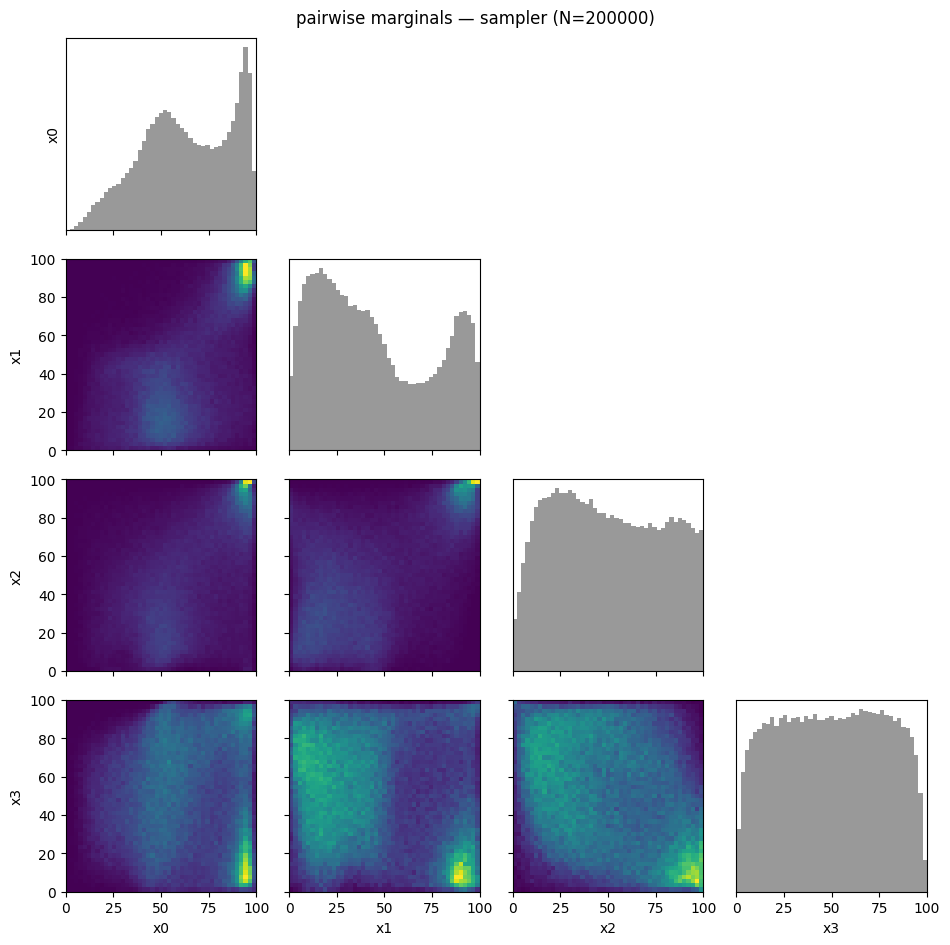

In [5]:
flow_plot_pairwise(fm, fp, bins=45, n_samples=200_000, seed=7)

In [6]:
t0 = time.time()
gm = GaussianModel([VarSpec(n, "gaussian", 0.0, 100.0) for n in names])

def gauss_loss(p):
    cov = gm._cov(p)
    return (W_EF * (gm.expectation(p, "x0") - 65.0) ** 2
            + W_EF * (gm.expectation(p, "x2") - 49.0) ** 2
            + W_EF * (gm.expectation(p, "x3") - 50.0) ** 2
            + W_P * (gm.prob(p, {"x1": (">", 60.0)}) - 0.30) ** 2
            + W_P * (gm.cond_prob(p, {"x1": (">", 60.0)}, {"x0": (">", 70.0)}) - 0.60) ** 2
            + W_P * (gm.cond_prob(p, {"x1": ("<", 30.0)}, {"x0": ("<", 40.0)}) - 0.55) ** 2
            + W_EF * (gm.expectation(p, "x2", event={"x1": (">", 60.0)}) - 70.0) ** 2
            + W_EF * (gm.expectation(p, "x2", event={"x1": ("<", 60.0)}) - 40.0) ** 2
            + W_C * (cov[2, 3] + 250.0) ** 2
            + W_P * (gm.prob(p, {"x0": (">", 70.0), "x3": (">", 70.0)}) - 0.15) ** 2)

gp, gh = train(gauss_loss, gm.init_params(seed=1), TrainConfig(steps=2000, lr=0.03))
fits["gaussian"] = (gm, gp)
print(f"gaussian loss {gh[0]:.3f} -> {gh[-1]:.5f}   ({time.time()-t0:.0f}s)")

gaussian loss 55.040 -> 0.00000   (9s)


In [7]:
t0 = time.time()
# exact-uniform 20-bin encoder over [0,100] (grid table -> quantile edges 0,5,..,100)
grid = np.tile(np.linspace(0.0, 100.0, 2001), (NV, 1)).T
enc = TableEncoder(pd.DataFrame(grid, columns=names), n_bins_cont=NBINS)

from scipy.optimize import brentq
def tilt(mean):
    """1-D maxent histogram with E[x] = mean: exponential tilt of uniform."""
    c = centers / SPAN
    def gap(lam):
        w = np.exp(lam * (c - 0.5)); w /= w.sum()
        return w @ c - mean / SPAN
    lam = 0.0 if abs(gap(0.0)) < 1e-9 else brentq(gap, -60, 60)
    w = np.exp(lam * (c - 0.5)); return w / w.sum()

marg = {"x0": tilt(65.0), "x2": tilt(49.0), "x3": tilt(50.0),
        "x1": np.where(centers > 60, 0.30 / 8, 0.70 / 12)}   # P(x1>60)=0.30

iv_gt = lambda v, t: Interval(v, int(t / 5), NBINS)
iv_lt = lambda v, t: Interval(v, 0, int(t / 5))
cop_bag = [MarginalConstraint(n, tuple(marg[n])) for n in names] + [
    CondProbConstraint((iv_gt("x1", 60),), (iv_gt("x0", 70),), 0.60),
    CondProbConstraint((iv_lt("x1", 30),), (iv_lt("x0", 40),), 0.55),
    CondExpectConstraint("x2", (iv_gt("x1", 60),), 0.70),    # encoded units
    CondExpectConstraint("x2", (iv_lt("x1", 60),), 0.40),
    CondExpectConstraint("x3", (iv_gt("x2", 50),), 0.40),    # cov translation
    CondExpectConstraint("x3", (iv_lt("x2", 50),), 0.60),
    ProbConstraint((iv_gt("x0", 70), iv_gt("x3", 70)), 0.15),
]
cop = GaussianCopulaEngine().fit(enc, cop_bag, seed=0).model
x_cop = cop.sample(None, 200_000, seed=7) * SPAN
print(f"copula   fit R over {len(cop_bag)} bag constraints   ({time.time()-t0:.0f}s)")

copula   fit R over 11 bag constraints   (6s)


### Constraint satisfaction

Read back with each model's *native* query machinery — exact contractions for
the tensor networks, closed-form Gaussian queries for `gaussian`, 200k samples
with **hard** indicators for `flow` and `copula`. Errors are normalised so
mixed units compare: probabilities as-is, expectations / span,
covariance / (span/2)².

In [8]:
def eval_tc(m, p):
    e2 = m.expectation(p, {2: centers}); e3 = m.expectation(p, {3: centers})
    exy = m.expectation(p, ((2, 3), np.outer(centers, centers)))
    return [
        m.expectation(p, {0: centers}), e2, e3,
        m.event_prob(p, {1: mgt(60)}),
        m.cond_prob(p, {1: mgt(60)}, {0: mgt(70)}),
        m.cond_prob(p, {1: mlt(30)}, {0: mlt(40)}),
        m.cond_expectation(p, 2, {1: mgt(60)}),
        m.cond_expectation(p, 2, {1: mlt(60)}),
        exy - e2 * e3,
        m.event_prob(p, {0: mgt(70), 3: mgt(70)}),
    ]

def eval_samples(x):
    gt = lambda i, t: x[:, i] > t
    return [
        x[:, 0].mean(), x[:, 2].mean(), x[:, 3].mean(),
        gt(1, 60).mean(),
        gt(1, 60)[gt(0, 70)].mean(),
        (~gt(1, 30))[~gt(0, 40)].mean(),
        x[gt(1, 60), 2].mean(),
        x[~gt(1, 60), 2].mean(),
        np.cov(x[:, 2], x[:, 3])[0, 1],
        (gt(0, 70) & gt(3, 70)).mean(),
    ]

def eval_gauss(gm, p):
    f = lambda v: float(v)
    return [
        f(gm.expectation(p, "x0")), f(gm.expectation(p, "x2")),
        f(gm.expectation(p, "x3")),
        f(gm.prob(p, {"x1": (">", 60.0)})),
        f(gm.cond_prob(p, {"x1": (">", 60.0)}, {"x0": (">", 70.0)})),
        f(gm.cond_prob(p, {"x1": ("<", 30.0)}, {"x0": ("<", 40.0)})),
        f(gm.expectation(p, "x2", event={"x1": (">", 60.0)})),
        f(gm.expectation(p, "x2", event={"x1": ("<", 60.0)})),
        float(np.asarray(gm._cov(p))[2, 3]),
        f(gm.prob(p, {"x0": (">", 70.0), "x3": (">", 70.0)})),
    ]

LABELS = ["E[x0]=65", "E[x2]=49", "E[x3]=50", "P(x1>60)=0.30",
          "P(x1>60|x0>70)=0.60", "P(x1<30|x0<40)=0.55",
          "E[x2|x1>60]=70", "E[x2|x1<60]=40",
          "cov(x2,x3)=-250", "P(x0>70,x3>70)=0.15"]
TARGETS = [65, 49, 50, 0.30, 0.60, 0.55, 70, 40, -250, 0.15]
NORM = [SPAN, SPAN, SPAN, 1, 1, 1, SPAN, SPAN, 2500, 1]

fitted = {"independent": eval_tc(*fits["independent"]),
          "chain": eval_tc(*fits["chain"]),
          "tree": eval_tc(*fits["tree"]),
          "flow": eval_samples(x_flow),
          "gaussian": eval_gauss(*fits["gaussian"]),
          "copula": eval_samples(x_cop)}

hdr = "".join(f"{m:>9s}" for m in COLOR)
print(f"{'constraint':<22s} {'target':>8s}{hdr}")
for k, lab in enumerate(LABELS):
    fmt = (lambda v: f"{v:9.3f}") if NORM[k] == 1 else (lambda v: f"{v:9.1f}")
    print(f"{lab:<22s} {fmt(TARGETS[k])[1:]}"
          + "".join(fmt(fitted[m][k]) for m in COLOR))

constraint               targetindependent    chain     tree     flow gaussian   copula
E[x0]=65                   65.0     65.0     64.9     64.7     63.2     65.0     65.0
E[x2]=49                   49.0     51.3     49.0     48.9     50.1     49.0     49.0
E[x3]=50                   50.0     44.2     49.9     50.0     49.9     50.0     50.0
P(x1>60)=0.30             0.300    0.450    0.301    0.301    0.315    0.300    0.299
P(x1>60|x0>70)=0.60       0.600    0.450    0.599    0.602    0.649    0.600    0.434
P(x1<30|x0<40)=0.55       0.550    0.549    0.550    0.542    0.554    0.550    0.622
E[x2|x1>60]=70             70.0     51.3     69.9     70.6     72.4     70.0     70.0
E[x2|x1<60]=40             40.0     51.3     39.9     39.5     39.8     40.0     40.0
cov(x2,x3)=-250          -250.0      0.0   -240.2   -240.0   -242.6   -250.0   -352.4
P(x0>70,x3>70)=0.15       0.150    0.150    0.149    0.150    0.131    0.150    0.149


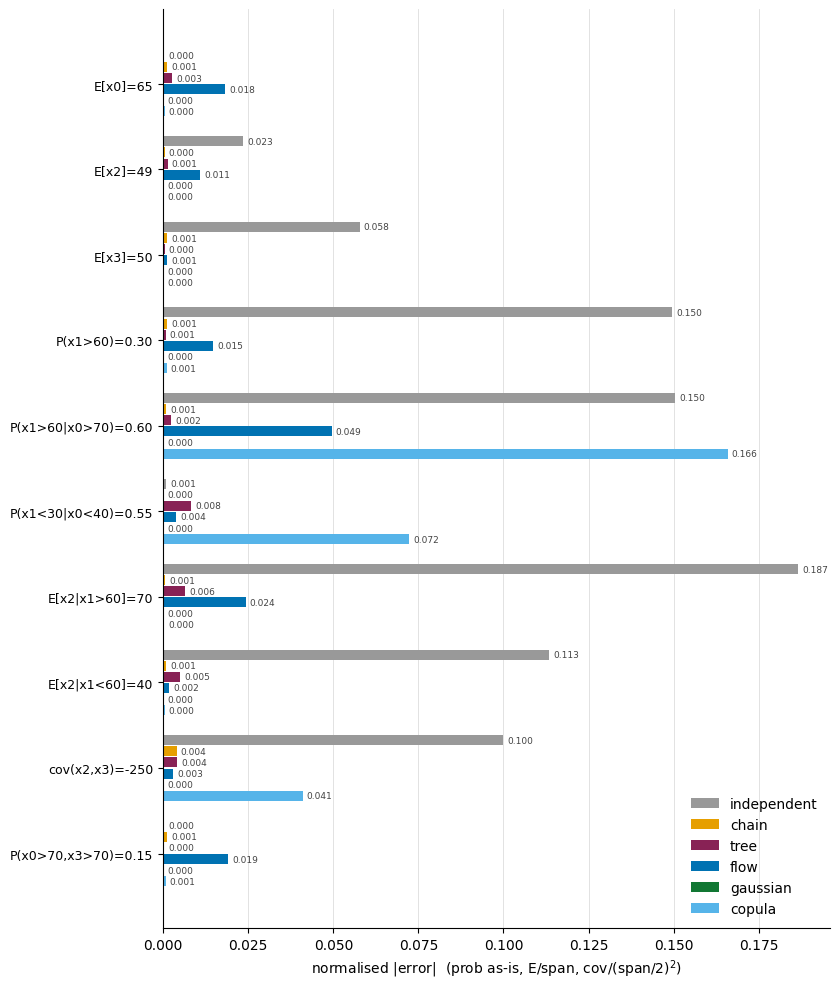

In [9]:
fig, ax = plt.subplots(figsize=(8.5, 10))
nm = len(COLOR)
ypos = np.arange(len(LABELS))[::-1] * 1.0
bh = 0.13
for s, (mname, col) in enumerate(COLOR.items()):
    errs = [abs(fitted[mname][k] - TARGETS[k]) / NORM[k] for k in range(len(LABELS))]
    bars = ax.barh(ypos + (nm / 2 - 0.5 - s) * bh, errs, height=bh * 0.9,
                   color=col, label=mname)
    for b, e in zip(bars, errs):
        ax.annotate(f"{e:.3f}", (b.get_width(), b.get_y() + b.get_height() / 2),
                    xytext=(3, 0), textcoords="offset points",
                    va="center", fontsize=6.5, color="#444444")
ax.set_yticks(ypos, LABELS, fontsize=9)
ax.set_xlabel("normalised |error|  (prob as-is, E/span, cov/(span/2)$^2$)")
ax.legend(frameon=False, loc="lower right")
ax.spines[["top", "right"]].set_visible(False)
ax.xaxis.grid(True, color="#dddddd", lw=0.6)
ax.set_axisbelow(True)
plt.tight_layout()
plt.show()

### Joint structure — corner plots

The two shared corner-plot helpers, one per model family: `tn.plot_pairwise`
draws **exact** pair marginals by contraction (used directly for the chains
and, via a thin site-marginal shim, for the tree — its own site indexing
includes the latent junctions); `maxent_sampler.plot_pairwise` is the
sample-histogram parallel (used directly for the flow and, via a sample shim,
for the gaussian and copula). Each model keeps its own sequential ramp; dashed
lines mark the constraint thresholds (`x0 > 70`, `x1 > 60`, `x3 > 70`).

Things to look for: the `x0-x1` and `x1-x2` panels carry the conditional
constraints, `x2-x3` the negative covariance, `x0-x3` the joint tail; in the
gray figure all of those panels are exactly rank-one. The gaussian is one
ellipsoid by construction — smooth but structurally unimodal — and the copula's
marginals are *exactly* its stage-1 histograms while all its dependence is one
correlation matrix.

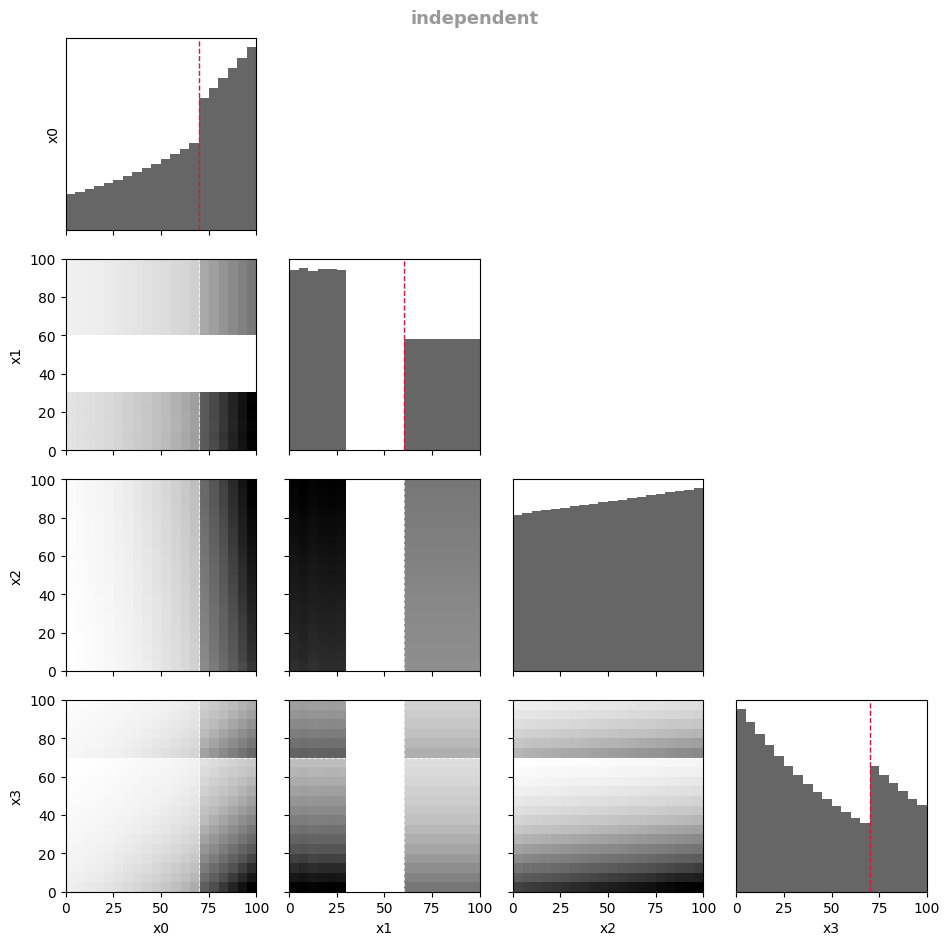

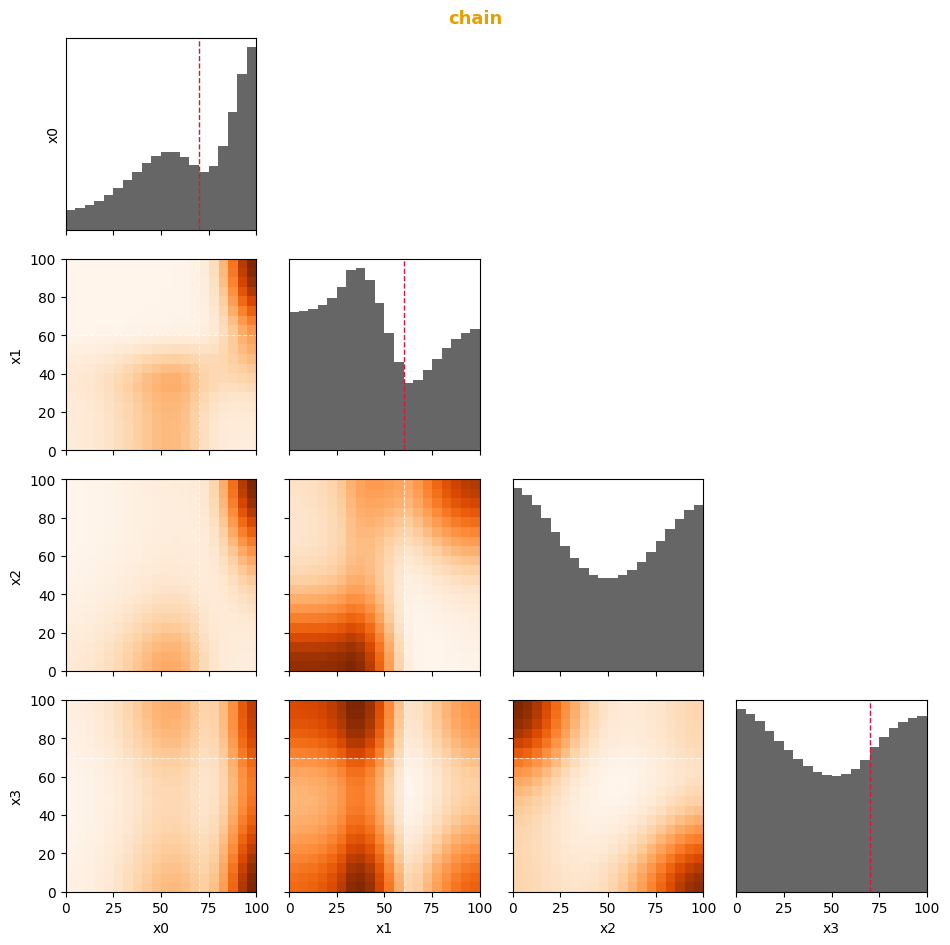

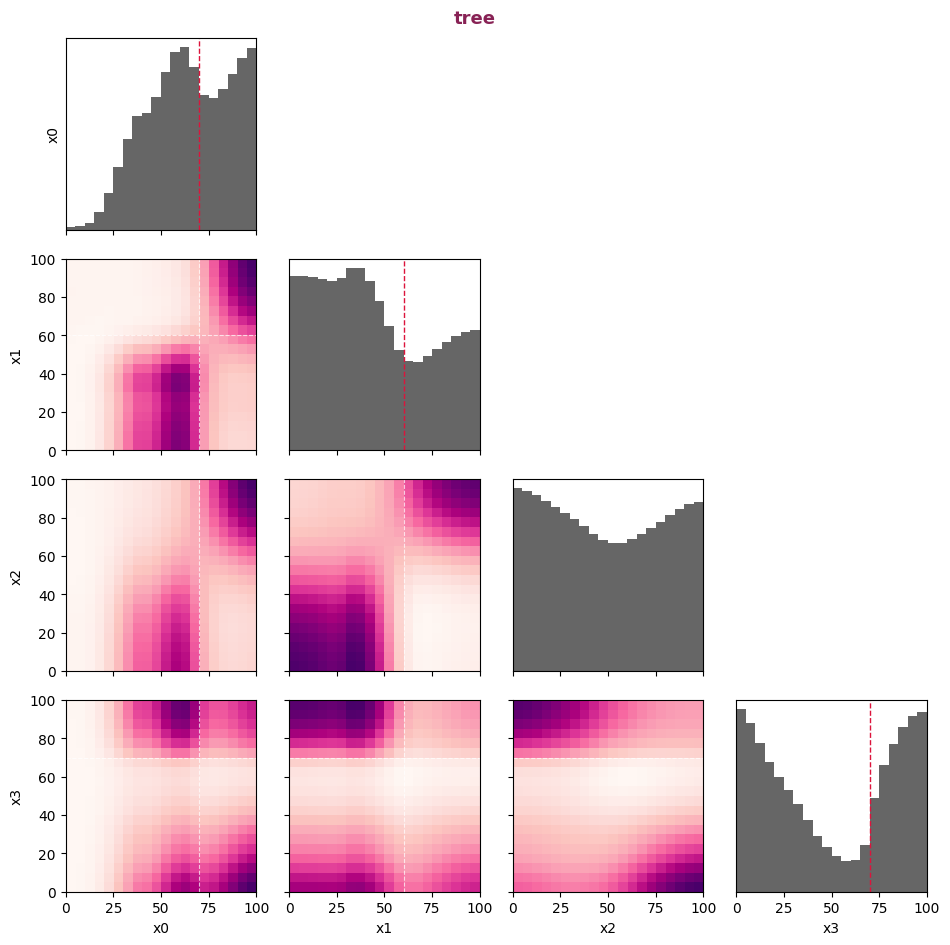

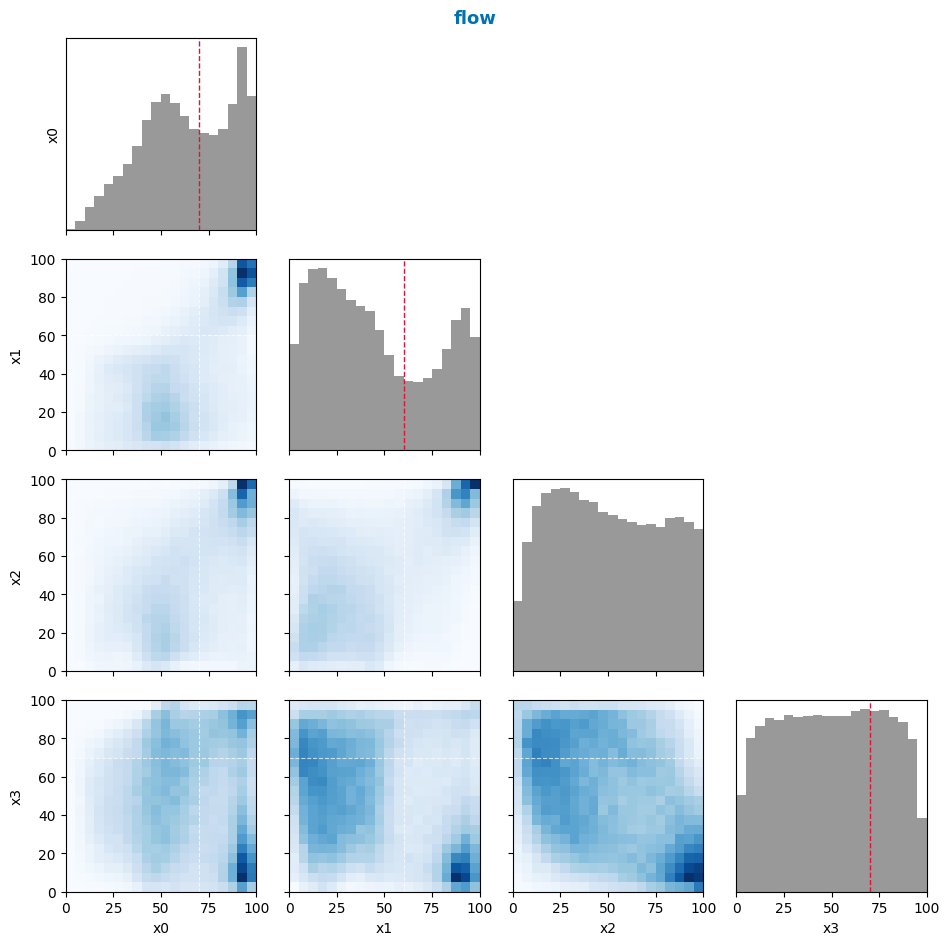

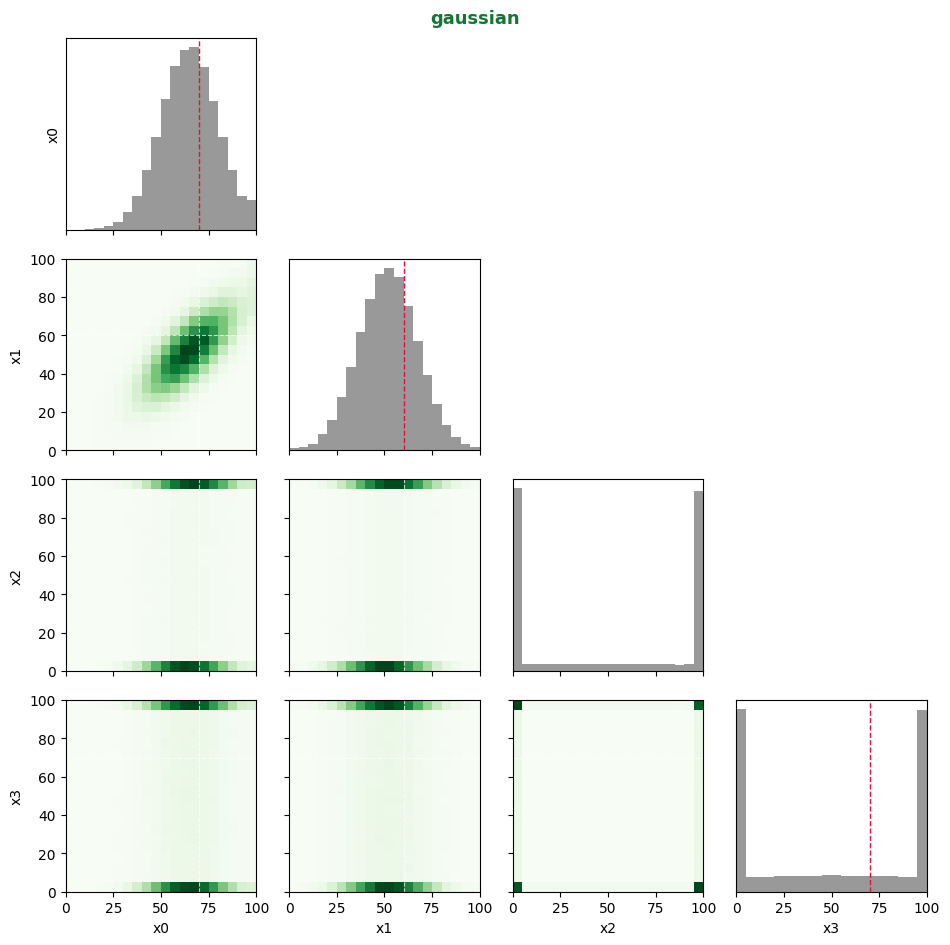

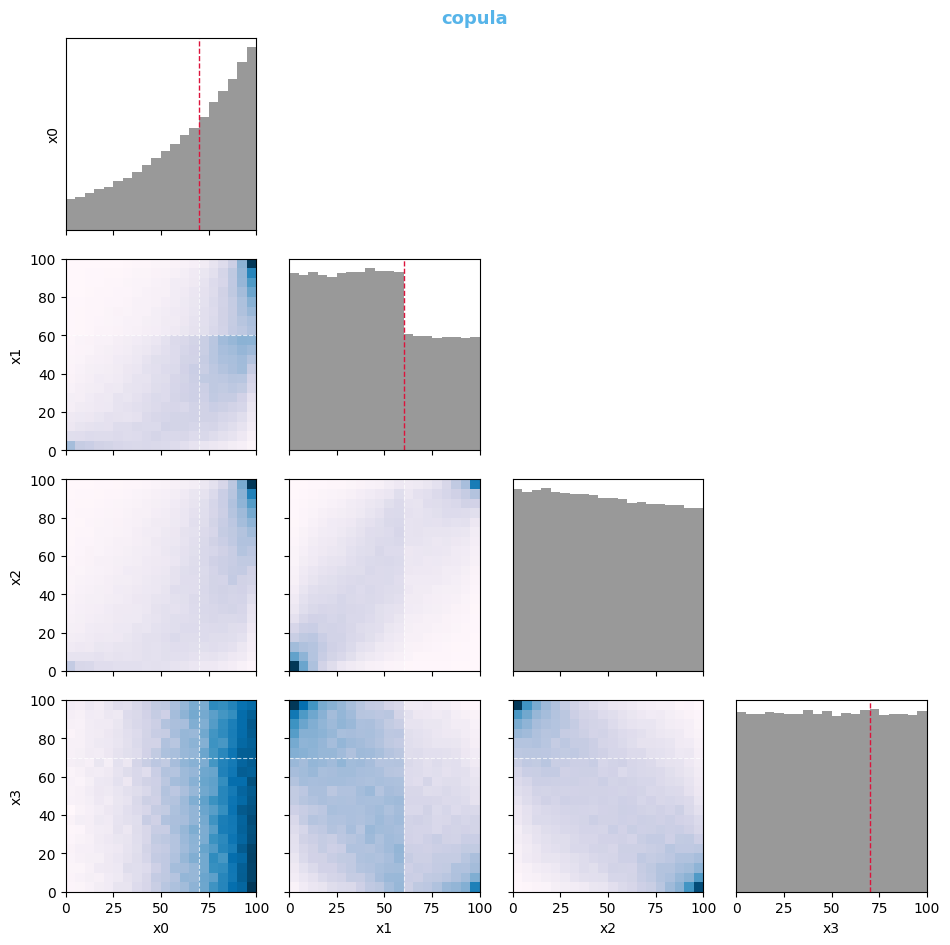

In [10]:
THR = {"x0": 70, "x1": 60, "x3": 70}
disc = fits["chain"][0].disc

def tc_view(m):        # leaves-only marginal view for tn_plot_pairwise
    return types.SimpleNamespace(
        disc=disc, n=NV, kind=m.kind, r=m.r,
        site_marginal=lambda p, i: np.asarray(m.joint_marginal(p, (i,))),
        pair_marginal=lambda p, i, j: np.asarray(m.joint_marginal(p, (j, i))).T)

def sample_view(fn):   # sample-only view for flow_plot_pairwise
    return types.SimpleNamespace(disc=disc, n=NV,
                                 sample=lambda p, n, seed=0: fn(n, seed))

corner = {
    "independent": lambda: tn_plot_pairwise(*fits["independent"], names=names,
                                            cmap=CMAP["independent"], threshold=THR),
    "chain": lambda: tn_plot_pairwise(*fits["chain"], names=names,
                                      cmap=CMAP["chain"], threshold=THR),
    "tree": lambda: tn_plot_pairwise(tc_view(fits["tree"][0]), fits["tree"][1],
                                     names=names, cmap=CMAP["tree"], threshold=THR),
    "flow": lambda: flow_plot_pairwise(fm, fp, names=names, cmap=CMAP["flow"],
                                       bins=NBINS, n_samples=200_000, seed=7,
                                       threshold=THR),
    "gaussian": lambda: flow_plot_pairwise(
        sample_view(lambda n, s: np.asarray(gm.sample(gp, n, seed=s))), None,
        names=names, cmap=CMAP["gaussian"], bins=NBINS, n_samples=200_000,
        seed=7, threshold=THR),
    "copula": lambda: flow_plot_pairwise(
        sample_view(lambda n, s: cop.sample(None, n, seed=s) * SPAN), None,
        names=names, cmap=CMAP["copula"], bins=NBINS, n_samples=200_000,
        seed=7, threshold=THR),
}
for label, draw in corner.items():
    fig, _ = draw()
    fig.suptitle(label, color=COLOR[label], fontsize=13, fontweight="bold")
plt.show()

### Notes

- **The independent null is honest about what a product can do.** It matches
  every marginal-expressible target — including, sneakily, the *joint* tail
  #10, which it satisfies by inflating `P(x0>70)` and `P(x3>70)` until their
  product is 0.15 — but its conditionals collapse to marginals and its
  covariance is structurally zero. The error chart shows exactly which
  constraints *require* dependence.
- **Chain vs tree** is a topology story: both fit by exact queries to
  near-zero residuals, and the `x0-x3` edge crosses three bonds in the chain
  but two (via the root) in the tree. Both now carry `core_tv`: the chain's
  marginals are visibly smoother than the earlier unregularised run (which
  carved a literal hole in `x1`'s marginal), and the tree gets the same
  treatment on its leaf cores (junctions are skipped) — the regulariser trades
  a little constraint residual for amplitude smoothness on the raw cores.
- **The flow's residuals are Monte-Carlo scale** (fresh 2048-sample batch per
  step), and its densities are the smoothest of the box-native models — the
  sigmoid squash + exact entropy term rounds off hard plateau edges.
- **The gaussian's zero-residual column is a trap.** Every statement here is a
  <=2-variable box quantity with a Phi closed form, and the table shows all
  ten hit exactly — but those queries are evaluated on the *unbounded*
  Gaussian. Look at its corner plot: with no entropy term and nothing pinning
  the variances, the optimiser inflated `Sigma` until most of the density lies
  outside `[0,100]` (a huge sigma makes every conditional shift and the
  covariance cheap), so the distribution restricted to the box collapses to
  spikes at the edges of `x2` and `x3`. Exact constraint satisfaction, absurd
  joint — precisely the failure the maxent entropy term exists to prevent, and
  why the benchmark's gaussian engine always pins full marginal CDFs.
- **The copula splits the problem** — marginals exactly from stage 1 (zero
  residual on #1-#4 by construction), all dependence in one correlation
  matrix. Its two visible failures are both *structural*: a single
  `rho(x0,x1)` under the fixed two-level `x1` marginal cannot hit both
  conditional corners (fitted 0.43 / 0.62 against 0.60 / 0.55 — the full
  gaussian, free to bend its marginals, could), and its grammar cannot say
  "covariance", so the half-conditional translation of #9 over-delivers under
  graded Gaussian dependence (fitted cov ~ -350). Concrete
  constraint-language mismatch, which is what this notebook is for.
- Scoreboard shape: the box-native dependence-capable models (chain, tree,
  flow) land near zero everywhere with their characteristic textures —
  plateaus vs smoothness; independent and copula fail exactly where their
  structure says they must; the gaussian's perfect column is an artefact of an
  unbounded domain. Where the numbers agree, compare the corner plots: the
  spec is silent about most of the joint, and what a model does with that
  freedom is its inductive bias.